In [1]:
from tensorflow import keras

In [ ]:
!pip show tensorflow

Name: tensorflowNote: you may need to restart the kernel to use updated packages.

Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\Users\akash\anaconda3\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: 


In [ ]:
!pip show keras

Name: keras
Version: 3.11.2
Summary: Multi-backend Keras
Home-page: 
Author: 
Author-email: Keras team <keras-users@googlegroups.com>
License: Apache License 2.0
Location: c:\Users\akash\anaconda3\Lib\site-packages
Requires: absl-py, h5py, ml-dtypes, namex, numpy, optree, packaging, rich
Required-by: tensorflow
Note: you may need to restart the kernel to use updated packages.


In [10]:
import tensorflow.keras as keras
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import array_to_img, img_to_array, load_img

datagen = ImageDataGenerator(
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    fill_mode = 'reflect',
)

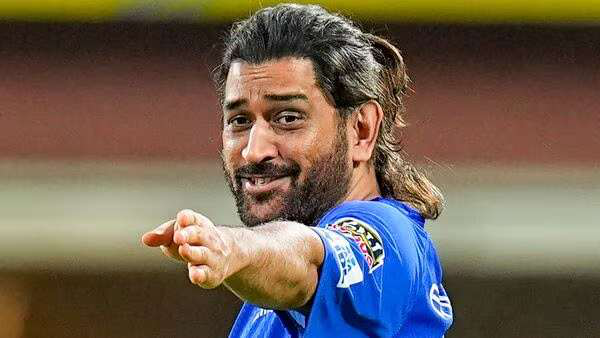

In [11]:
img = load_img('MS_Dhoni.jpg')
img

In [12]:
x = img_to_array(img)
x = x.reshape((1,) + x.shape)

i = 0
for batch in datagen.flow(x, batch_size=1,
                          save_to_dir = r'C:\Users\akash\OneDrive\Desktop\FSDS\AI\DL\KERAS PKGS',
                          save_prefix = 'dhoni', save_format = 'jpg'):
    i +=1
    if i > 10:
        break

In [13]:
keras.applications.ResNet50(
    include_top = True,
    weights = 'imagenet',
    input_tensor = None,
    input_shape = None,
    pooling = None,
    classes = 1000,
    classifier_activation = "softmax"
)

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


<Functional name=resnet50, built=True>

## 1. Basic Predictions of Image
## 2. ResNet50

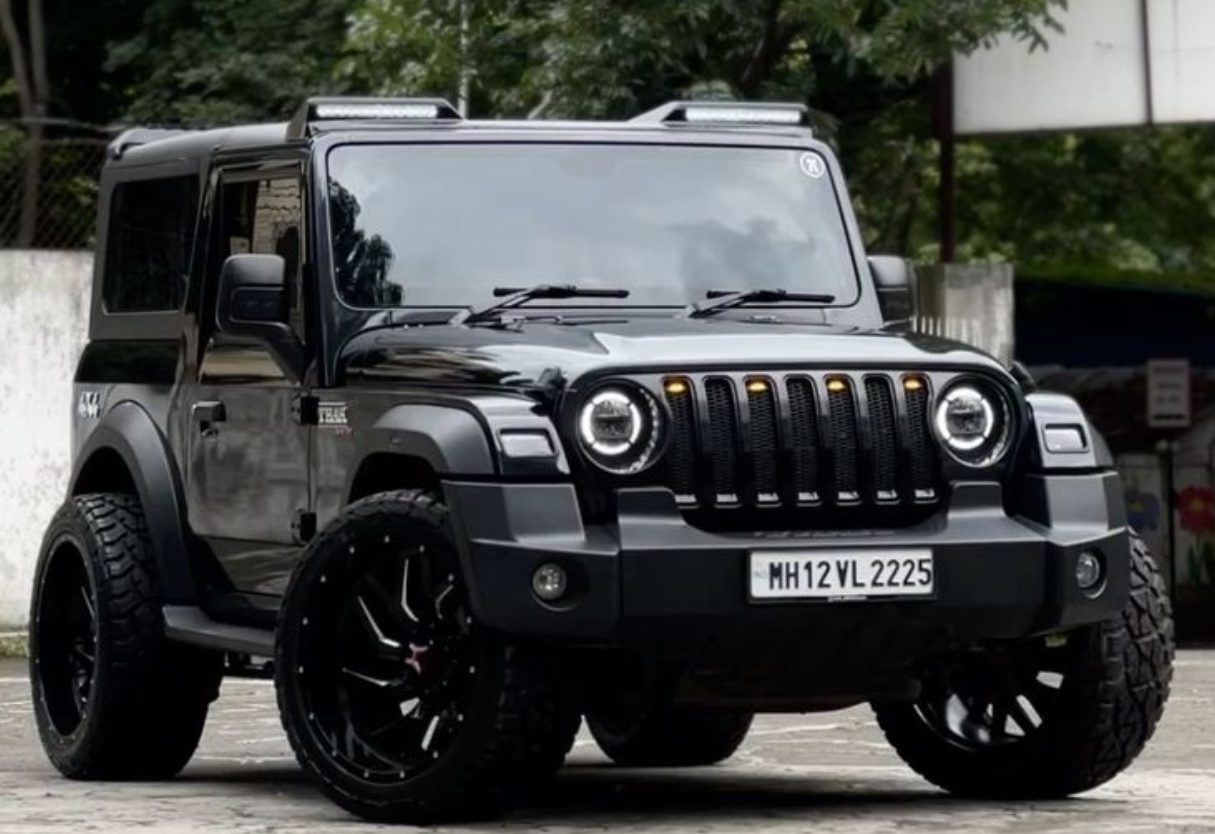

In [30]:
from keras.utils import array_to_img, img_to_array, load_img
img = load_img('thar.png')
img

In [31]:
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image

model = ResNet50(weights = 'imagenet')

img_path = 'thar.png'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# make prediction
predictions = model.predict(img_array)

#decode and print the top 3 predicted classes
decoded_predictions = decode_predictions(predictions, top=3)[0]

print("pridictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i+1}: {label} ({score:.2f})")

top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
pridictions:
1: jeep (0.99)
2: half_track (0.00)
3: snowplow (0.00)

Top Prediction Class Index: 609


In [32]:
import numpy as np
from tensorflow.keras.applications.resnet_v2 import ResNet50V2,preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
model = ResNet50V2(weights = 'imagenet')

img_path = 'cat.jpg'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

predictions = model.predict(img_array)
decoded_predictions = decode_predictions(predictions, top=3)[0]
print("Predictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i + 1}: {label} ({score:.2f})")

top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predictions:
1: tabby (0.91)
2: tiger_cat (0.09)
3: Egyptian_cat (0.00)

Top Prediction Class Index: 281


## VGG16

In [34]:
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16,preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
model = ResNet50V2(weights = 'imagenet')

img_path = 'thar.png'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

predictions = model.predict(img_array)
decoded_predictions = decode_predictions(predictions, top=3)[0]

print("Predictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i + 1}: {label} ({score:.2f})")

top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predictions:
1: fox_squirrel (0.92)
2: English_foxhound (0.08)
3: rapeseed (0.00)

Top Prediction Class Index: 335


## VGG19

In [43]:
import numpy as np
from keras.utils import load_img
from tensorflow.keras.applications.vgg19 import VGG19,preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
model = ResNet50V2(weights = 'imagenet')

img_path = 'dog.jpeg'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

predictions = model.predict(img_array)
decoded_predictions = decode_predictions(predictions, top=3)[0]

print("Predictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i + 1}: {label} ({score:.2f})")

top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions:
1: English_foxhound (1.00)
2: Japanese_spaniel (0.00)
3: rapeseed (0.00)

Top Prediction Class Index: 167


In [ ]:
import numpy as np
from tensorflow.keras.applications.resnet_v2 import ResNet50V2,preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
model = ResNet50V2(weights = 'imagenet')

img_path = 'dog.jpeg'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

predictions = model.predict(img_array)
decoded_predictions = decode_predictions(predictions, top=10)[0]

print("Predictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i + 1}: {label} ({score:.2f})")

top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predictions:
1: golden_retriever (0.96)
2: Labrador_retriever (0.03)
3: kuvasz (0.00)
4: redbone (0.00)
5: Rhodesian_ridgeback (0.00)
6: tennis_ball (0.00)
7: Tibetan_mastiff (0.00)
8: dingo (0.00)
9: collie (0.00)
10: Saluki (0.00)

Top Prediction Class Index: 207


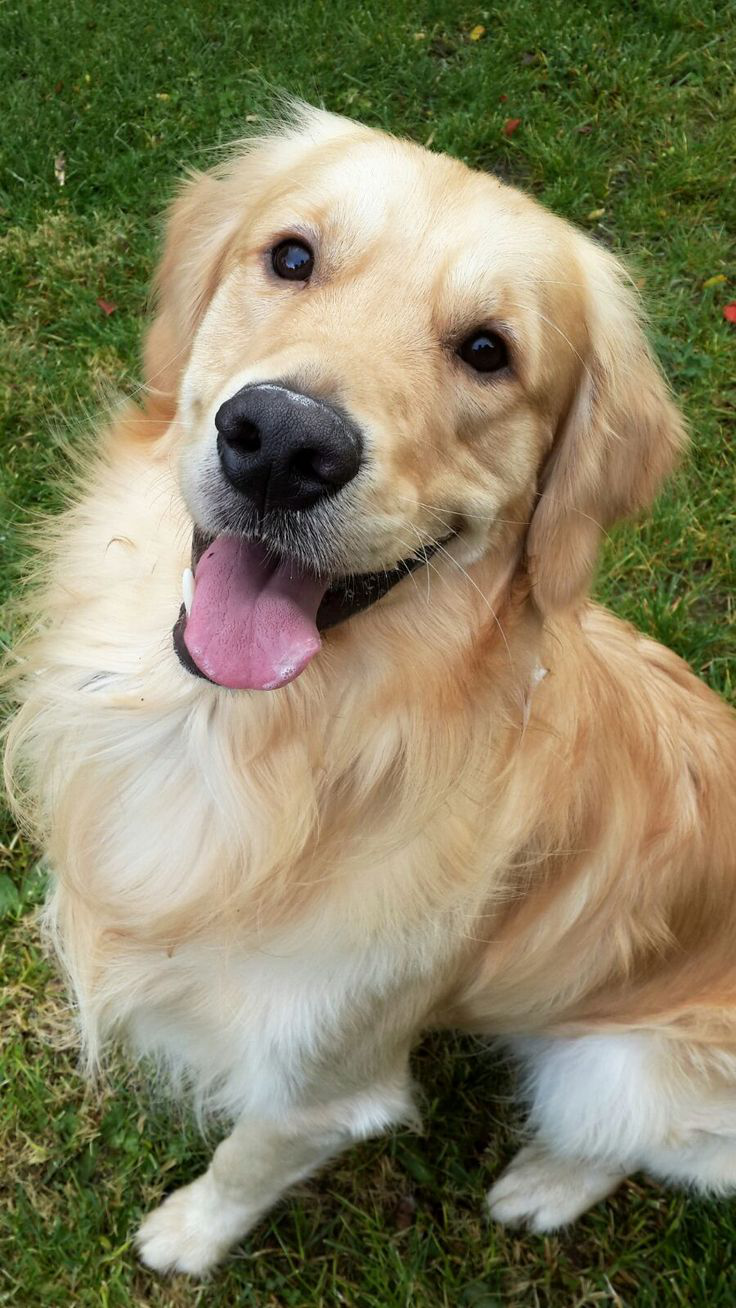

In [45]:
from tensorflow.keras.preprocessing import image
img = image.load_img(r'dog.jpeg')
img

In [48]:
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
model = ResNet50V2(weights = 'imagenet')

img_path = 'dog.jpeg'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# measure inference time
import time
start_time = time.time()


predictions = model.predict(img_array)
end_time = time.time()

decoded_predictions = decode_predictions(predictions, top=5)[0]

print("Predictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i + 1}: {label} ({score:.2f})")

top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

#calculate and print inference time 
inference_time = (end_time - start_time) * 1000.0
print(f"Inference Time : {inference_time:.2f} ms")

#get the size of model in MB
model_size = model.count_params() * 4 / (1024**2)
print(f"Size (MB): {model_size:.2f} MB")

num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters: {num_parameters} \nDepth: {model_depth}")




1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions:
1: English_foxhound (1.00)
2: Japanese_spaniel (0.00)
3: rapeseed (0.00)
4: tench (0.00)
5: toilet_tissue (0.00)

Top Prediction Class Index: 167
Inference Time : 1819.57 ms
Size (MB): 97.71 MB
Parameters: 25613800 
Depth: 192


In [1]:
import numpy as np
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
model = ResNet50V2(weights = 'imagenet')

img_path = 'thar.png'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# measure inference time
import time
start_time = time.time()


predictions = model.predict(img_array)
end_time = time.time()

decoded_predictions = decode_predictions(predictions, top=5)[0]

print("Predictions:")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i + 1}: {label} ({score:.2f})")

top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

#calculate and print inference time 
inference_time = (end_time - start_time) * 1000.0
print(f"Inference Time : {inference_time:.2f} ms")

#get the size of model in MB
model_size = model.count_params() * 4 / (1024**2)
print(f"Size (MB): {model_size:.2f} MB")

num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters: {num_parameters} \nDepth: {model_depth}")




1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions:
1: jeep (1.00)
2: half_track (0.00)
3: golfcart (0.00)
4: police_van (0.00)
5: garbage_truck (0.00)

Top Prediction Class Index: 609
Inference Time : 2204.42 ms
Size (MB): 97.71 MB
Parameters: 25613800 
Depth: 192


In [4]:
import numpy as np
from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import time

# Load VGG19 pre-trained model 
model = VGG19(weights = 'imagenet')

# load and preprocess input image
img_path = 'dog.jpeg'

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# measure inference time 
start_time = time.time()
predictions = model.predict(img_array)
end_time = time.time()

# decode and print top-5 predicted classes
decoded_predictions = decode_predictions(predictions, top=5)[0]

print("prediction")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i + 1}: {label} ({score:.2f})")

# Optionally, you can obtain the class index for top predictions
top_class_index = np.argmax(predictions[0])
print(f"nTop Prediction Class Index: {top_class_index}")

#calculate and print the inference time per step
inference_time_ms = (end_time - start_time) * 1000.0
print(f"Inference Time: {inference_time_ms:.2f}ms")

# Get the size of the model 
model_size_MB = model.count_params() * 4 / (1024 **2)
print(f"Size (MB): {model_size_MB} MB")

# Get the No. of parameters and depth from the model's layers
num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters : {num_parameters}")
print(f"Depth: {model_depth}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
prediction
1: golden_retriever (0.75)
2: Labrador_retriever (0.16)
3: soccer_ball (0.02)
4: tennis_ball (0.01)
5: kuvasz (0.01)
nTop Prediction Class Index: 207
Inference Time: 605.06ms
Size (MB): 548.0470275878906 MB
Parameters : 143667240
Depth: 26


In [5]:
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import time

# Load VGG16 pre-trained model 
model = VGG16(weights = 'imagenet')

# load and preprocess input image
img_path = 'dog.jpeg'

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)

# measure inference time 
start_time = time.time()
predictions = model.predict(img_array)
end_time = time.time()

# decode and print top-5 predicted classes
decoded_predictions = decode_predictions(predictions, top=5)[0]

print("prediction")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    print(f"{i + 1}: {label} ({score:.2f})")

# Optionally, you can obtain the class index for top predictions
top_class_index = np.argmax(predictions[0])
print(f"nTop Prediction Class Index: {top_class_index}")

#calculate and print the inference time per step
inference_time_ms = (end_time - start_time) * 1000.0
print(f"Inference Time: {inference_time_ms:.2f}ms")

# Get the size of the model 
model_size_MB = model.count_params() * 4 / (1024 **2)
print(f"Size (MB): {model_size_MB} MB")

# Get the No. of parameters and depth from the model's layers
num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters : {num_parameters}")
print(f"Depth: {model_depth}")

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 138s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
prediction
1: golden_retriever (0.55)
2: Labrador_retriever (0.35)
3: Pembroke (0.02)
4: kuvasz (0.02)
5: tennis_ball (0.01)
nTop Prediction Class Index: 207
Inference Time: 1529.03ms
Size (MB): 527.7921447753906 MB
Parameters : 138357544
Depth: 23


In [12]:
import numpy as np
from tensorflow.keras.applications import Xception
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.xception import preprocess_input, decode_predictions
import time

# Load Xception pre-trained model 
model = Xception(weights = 'imagenet')

# load and preprocess input image
img_path = 'thar.png'
img = image.load_img(img_path, target_size = (299, 299))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis = 0)
img_array = preprocess_input(img_array)

# Measure Inference time
start_time = time.time()
predictions = model.predict(img_array)
end_time = time.time()

#  Decode and print the top-5 predicted classes
decoded_predictions = decode_predictions(predictions, top=5)

print("Predictions")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions[0]):
    print(f"{i+1}: {label} ({score:.2f})")

# Optionally, you can obtain the class index for the top prediction
top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

# Calculate and print the inference time per step
inference_time_ms = (end_time-start_time)*1000.0
print(f"Inference Time: {inference_time_ms} ms")

# Get the size of the model in megabytes
model_size_MB = model.count_params() *4 /(1024**2)
print(f"Size (MB): {model_size_MB}")

# Get the number of parameters and depth from the model's layers
num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters: {num_parameters}")
print(f"Depth: {model_depth}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 960ms/step
Predictions
1: jeep (0.94)
2: car_wheel (0.00)
3: ambulance (0.00)
4: pickup (0.00)
5: police_van (0.00)

Top Prediction Class Index: 609
Inference Time: 993.9751625061035 ms
Size (MB): 87.39654541015625
Parameters: 22910480
Depth: 134


In [13]:
import numpy as np
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.inception_v3 import preprocess_input, decode_predictions
import time

# Load InceptionV3 pre-trained model 
model = InceptionV3(weights = 'imagenet')

# load and preprocess input image
img_path = 'thar.png'
img = image.load_img(img_path, target_size = (299, 299))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis = 0)
img_array = preprocess_input(img_array)

# Measure Inference time
start_time = time.time()
predictions = model.predict(img_array)
end_time = time.time()

#  Decode and print the top-5 predicted classes
decoded_predictions = decode_predictions(predictions, top=5)

print("Predictions")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions[0]):
    print(f"{i+1}: {label} ({score:.2f})")

# Optionally, you can obtain the class index for the top prediction
top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

# Calculate and print the inference time per step
inference_time_ms = (end_time-start_time)*1000.0
print(f"Inference Time: {inference_time_ms} ms")

# Get the size of the model in megabytes
model_size_MB = model.count_params() *4 /(1024**2)
print(f"Size (MB): {model_size_MB}")

# Get the number of parameters and depth from the model's layers
num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters: {num_parameters}")
print(f"Depth: {model_depth}")


96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions
1: jeep (0.81)
2: half_track (0.08)
3: tank (0.01)
4: ambulance (0.00)
5: limousine (0.00)

Top Prediction Class Index: 609
Inference Time: 2171.7617511749268 ms
Size (MB): 90.98733520507812
Parameters: 23851784
Depth: 313


In [15]:
import numpy as np
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
import time

# Load MobileNetV2 pre-trained model 
model = MobileNetV2(weights = 'imagenet')

# load and preprocess input image
img_path = 'thar.png'
img = image.load_img(img_path, target_size = (224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis = 0)
img_array = preprocess_input(img_array)

# Measure Inference time
start_time = time.time()
predictions = model.predict(img_array)
end_time = time.time()

#  Decode and print the top-5 predicted classes
decoded_predictions = decode_predictions(predictions, top=5)

print("Predictions")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions[0]):
    print(f"{i+1}: {label} ({score:.2f})")

# Optionally, you can obtain the class index for the top prediction
top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

# Calculate and print the inference time per step
inference_time_ms = (end_time-start_time)*1000.0
print(f"Inference Time: {inference_time_ms} ms")

# Get the size of the model in megabytes
model_size_MB = model.count_params() *4 /(1024**2)
print(f"Size (MB): {model_size_MB}")

# Get the number of parameters and depth from the model's layers
num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters: {num_parameters}")
print(f"Depth: {model_depth}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predictions
1: jeep (0.63)
2: ambulance (0.05)
3: half_track (0.04)
4: tow_truck (0.02)
5: police_van (0.01)

Top Prediction Class Index: 609
Inference Time: 1050.0171184539795 ms
Size (MB): 13.500152587890625
Parameters: 3538984
Depth: 156


In [16]:
import numpy as np
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.densenet import preprocess_input, decode_predictions
import time

# Load DenseNet121 pre-trained model 
model = DenseNet121(weights = 'imagenet')

# load and preprocess input image
img_path = 'thar.png'
img = image.load_img(img_path, target_size = (224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis = 0)
img_array = preprocess_input(img_array)

# Measure Inference time
start_time = time.time()
predictions = model.predict(img_array)
end_time = time.time()

#  Decode and print the top-5 predicted classes
decoded_predictions = decode_predictions(predictions, top=5)

print("Predictions")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions[0]):
    print(f"{i+1}: {label} ({score:.2f})")

# Optionally, you can obtain the class index for the top prediction
top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

# Calculate and print the inference time per step
inference_time_ms = (end_time-start_time)*1000.0
print(f"Inference Time: {inference_time_ms} ms")

# Get the size of the model in megabytes
model_size_MB = model.count_params() *4 /(1024**2)
print(f"Size (MB): {model_size_MB}")

# Get the number of parameters and depth from the model's layers
num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters: {num_parameters}")
print(f"Depth: {model_depth}")


33188688/33188688 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Predictions
1: jeep (1.00)
2: golfcart (0.00)
3: half_track (0.00)
4: pickup (0.00)
5: tow_truck (0.00)

Top Prediction Class Index: 609
Inference Time: 5456.707715988159 ms
Size (MB): 30.756011962890625
Parameters: 8062504
Depth: 429


In [17]:
import numpy as np
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.nasnet import preprocess_input, decode_predictions
import time

# Load NASNetMobile pre-trained model 
model = NASNetMobile(weights = 'imagenet')

# load and preprocess input image
img_path = 'thar.png'
img = image.load_img(img_path, target_size = (224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis = 0)
img_array = preprocess_input(img_array)

# Measure Inference time
start_time = time.time()
predictions = model.predict(img_array)
end_time = time.time()

#  Decode and print the top-5 predicted classes
decoded_predictions = decode_predictions(predictions, top=5)

print("Predictions")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions[0]):
    print(f"{i+1}: {label} ({score:.2f})")

# Optionally, you can obtain the class index for the top prediction
top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

# Calculate and print the inference time per step
inference_time_ms = (end_time-start_time)*1000.0
print(f"Inference Time: {inference_time_ms} ms")

# Get the size of the model in megabytes
model_size_MB = model.count_params() *4 /(1024**2)
print(f"Size (MB): {model_size_MB}")

# Get the number of parameters and depth from the model's layers
num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters: {num_parameters}")
print(f"Depth: {model_depth}")


24227760/24227760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predictions
1: jeep (0.96)
2: half_track (0.00)
3: amphibian (0.00)
4: ambulance (0.00)
5: pickup (0.00)

Top Prediction Class Index: 609
Inference Time: 4123.787403106689 ms
Size (MB): 20.319808959960938
Parameters: 5326716
Depth: 771


In [18]:
import numpy as np
from tensorflow.keras.applications import NASNetLarge
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.nasnet import preprocess_input, decode_predictions
import time

# Load NASNetLarge pre-trained model 
model = NASNetLarge(weights = 'imagenet')

# load and preprocess input image
img_path = 'thar.png'
img = image.load_img(img_path, target_size = (331, 331))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis = 0)
img_array = preprocess_input(img_array)

# Measure Inference time
start_time = time.time()
predictions = model.predict(img_array)
end_time = time.time()

#  Decode and print the top-5 predicted classes
decoded_predictions = decode_predictions(predictions, top=5)

print("Predictions")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions[0]):
    print(f"{i+1}: {label} ({score:.2f})")

# Optionally, you can obtain the class index for the top prediction
top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

# Calculate and print the inference time per step
inference_time_ms = (end_time-start_time)*1000.0
print(f"Inference Time: {inference_time_ms} ms")

# Get the size of the model in megabytes
model_size_MB = model.count_params() *4 /(1024**2)
print(f"Size (MB): {model_size_MB}")

# Get the number of parameters and depth from the model's layers
num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters: {num_parameters}")
print(f"Depth: {model_depth}")


359748576/359748576 ━━━━━━━━━━━━━━━━━━━━ 50s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predictions
1: jeep (0.87)
2: car_wheel (0.00)
3: grille (0.00)
4: beach_wagon (0.00)
5: limousine (0.00)

Top Prediction Class Index: 609
Inference Time: 5702.845335006714 ms
Size (MB): 339.3166275024414
Parameters: 88949818
Depth: 1041


In [19]:
import numpy as np
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input, decode_predictions
import time

# Load EfficientNetV2B0 pre-trained model 
model = EfficientNetV2B0(weights = 'imagenet')

# load and preprocess input image
img_path = 'thar.png'
img = image.load_img(img_path, target_size = (224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis = 0)
img_array = preprocess_input(img_array)

# Measure Inference time
start_time = time.time()
predictions = model.predict(img_array)
end_time = time.time()

#  Decode and print the top-5 predicted classes
decoded_predictions = decode_predictions(predictions, top=5)

print("Predictions")
for i, (imagenet_id, label, score) in enumerate(decoded_predictions[0]):
    print(f"{i+1}: {label} ({score:.2f})")

# Optionally, you can obtain the class index for the top prediction
top_class_index = np.argmax(predictions[0])
print(f"\nTop Prediction Class Index: {top_class_index}")

# Calculate and print the inference time per step
inference_time_ms = (end_time-start_time)*1000.0
print(f"Inference Time: {inference_time_ms} ms")

# Get the size of the model in megabytes
model_size_MB = model.count_params() *4 /(1024**2)
print(f"Size (MB): {model_size_MB}")

# Get the number of parameters and depth from the model's layers
num_parameters = model.count_params()
model_depth = len(model.layers)

print(f"Parameters: {num_parameters}")
print(f"Depth: {model_depth}")


29403144/29403144 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predictions
1: jeep (0.88)
2: limousine (0.01)
3: half_track (0.00)
4: car_wheel (0.00)
5: ambulance (0.00)

Top Prediction Class Index: 609
Inference Time: 1958.0943584442139 ms
Size (MB): 27.467010498046875
Parameters: 7200312
Depth: 273
